# Chẩn đoán ung thư vú bằng Machine Learning

## Bài toán
Phân loại khối u thành:
- B: Benign (lành tính)
- M: Malignant (ác tính)

## Mục tiêu
1. Khám phá dữ liệu
2. Tiền xử lý dữ liệu
3. Xây dựng các mô hình Classification
4. Đánh giá mô hình
5. So sánh kết quả
6. Chuẩn bị mô hình cho triển khai

In [ ]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Các thư viện đã được import thành công!")

Các thư viện đã được import thành công!


In [ ]:
!git clone https://github.com/YoungHyyy/18_10123154_12523066_CDUTV.git

Cloning into '18_10123154_12523066_CDUTV'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 57 (delta 16), reused 49 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 1.75 MiB | 16.63 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [ ]:
!ls

18_10123154_12523066_CDUTV  sample_data


In [ ]:
!ls "18_10123154_12523066_CDUTV/ai-models/data"

data.md  dataset.zip


In [ ]:
from pathlib import Path

ROOT = Path("/content/18_10123154_12523066_CDUTV")
DATA_ZIP = ROOT / "ai-models" / "data" / "dataset.zip"

with zipfile.ZipFile(DATA_ZIP, "r") as z:
    df = pd.read_csv(z.open("data.csv"))

print("Dataset shape:", df.shape)

Dataset shape: (569, 33)


In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (569, 33)
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [ ]:
print("Thông tin cột id:")
print(df["id"].head())

print("\nThông tin cột Unnamed: 32:")
print(df["Unnamed: 32"].head())

print("\nSố giá trị khác nhau của id:", df["id"].nunique())
print("Số giá trị khác nhau của Unnamed: 32:", df["Unnamed: 32"].nunique())

Thông tin cột id:
0      842302
1      842517
2    84300903
3    84348301
4    84358402
Name: id, dtype: int64

Thông tin cột Unnamed: 32:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Unnamed: 32, dtype: float64

Số giá trị khác nhau của id: 569
Số giá trị khác nhau của Unnamed: 32: 0


In [ ]:
print(df[["id", "Unnamed: 32"]].isnull().sum())

id               0
Unnamed: 32    569
dtype: int64


In [ ]:
print("===== THÔNG TIN DATASET =====")
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

print("\n===== KIỂU DỮ LIỆU =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE =====")
print("Số dòng trùng:", df.duplicated().sum())

===== THÔNG TIN DATASET =====
Số dòng: 569
Số cột: 33

===== KIỂU DỮ LIỆU =====
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness

In [ ]:
print(df["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
print(df["diagnosis"].value_counts(normalize=True) * 100)

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


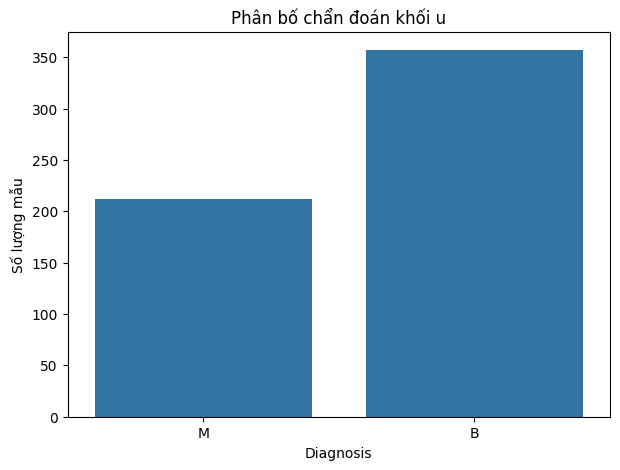

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="diagnosis")

plt.title("Phân bố chẩn đoán khối u")
plt.xlabel("Diagnosis")
plt.ylabel("Số lượng mẫu")

plt.show()

In [ ]:
df[["id", "Unnamed: 32"]].head()

,id,Unnamed: 32
0,842302,NaN
1,842517,NaN
2,84300903,NaN
3,84348301,NaN
4,84358402,NaN


In [ ]:
df[["id", "Unnamed: 32"]].isnull().sum()

,0
id,0
Unnamed: 32,569


In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
# Tạo bản sao để thực hiện tiền xử lý
df_clean = df.copy()

# Loại bỏ các cột không có giá trị sử dụng cho mô hình
df_clean = df_clean.drop(columns=["id", "Unnamed: 32"])

print("Kích thước trước khi làm sạch:", df.shape)
print("Kích thước sau khi làm sạch:", df_clean.shape)

Kích thước trước khi làm sạch: (569, 33)
Kích thước sau khi làm sạch: (569, 31)


In [ ]:
print(df_clean.columns.tolist())

['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [ ]:
print("Missing values:", df_clean.isnull().sum().sum())

Missing values: 0


In [ ]:
print("Số dòng trùng:", df_clean.duplicated().sum())

Số dòng trùng: 0


In [ ]:
X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [ ]:
df_clean = df.drop(columns=["id", "Unnamed: 32"])

print("Shape:", df_clean.shape)
print("Missing:", df_clean.isnull().sum().sum())
print("Duplicate:", df_clean.duplicated().sum())

Shape: (569, 31)
Missing: 0
Duplicate: 0


In [ ]:
X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [ ]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
X.describe().loc[["mean", "std", "min", "max"]].T

,mean,std,min,max
radius_mean,14.127292,3.524049,6.981000,28.11000
texture_mean,19.289649,4.301036,9.710000,39.28000
perimeter_mean,91.969033,24.298981,43.790000,188.50000
area_mean,654.889104,351.914129,143.500000,2501.00000
smoothness_mean,0.096360,0.014064,0.052630,0.16340
compactness_mean,0.104341,0.052813,0.019380,0.34540
concavity_mean,0.088799,0.079720,0.000000,0.42680
concave points_mean,0.048919,0.038803,0.000000,0.20120
symmetry_mean,0.181162,0.027414,0.106000,0.30400
fractal_dimension_mean,0.062798,0.007060,0.049960,0.09744


In [ ]:
features_to_plot = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean"
]

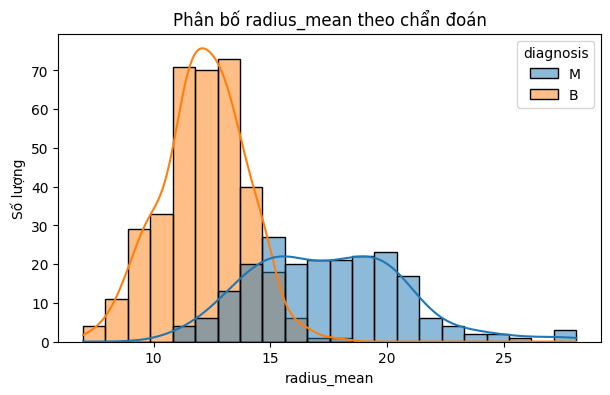

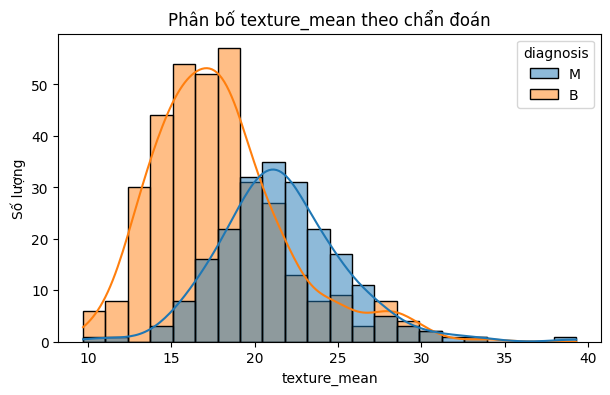

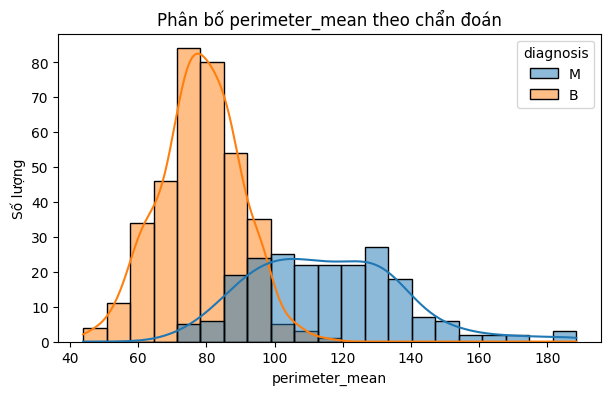

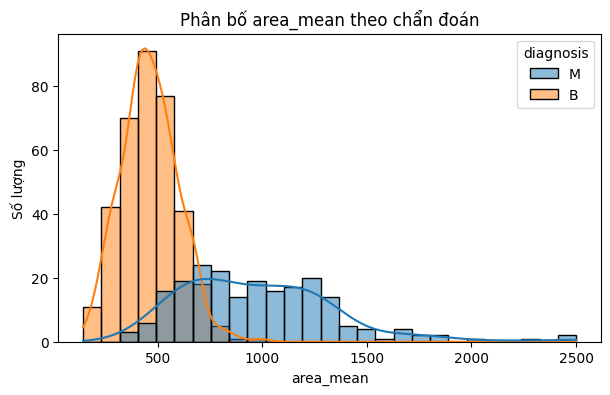

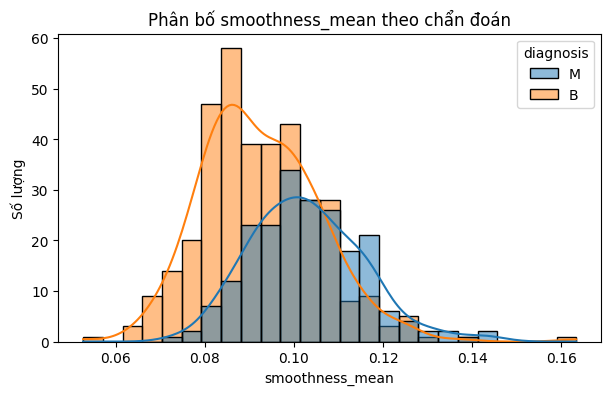

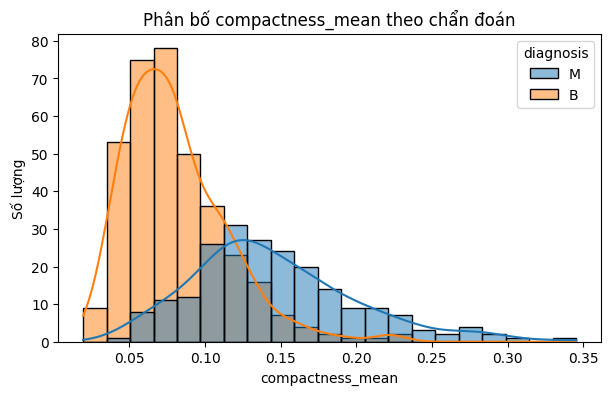

In [ ]:
for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df_clean, x=feature, hue="diagnosis", kde=True)
    plt.title(f"Phân bố {feature} theo chẩn đoán")
    plt.xlabel(feature)
    plt.ylabel("Số lượng")
    plt.show()

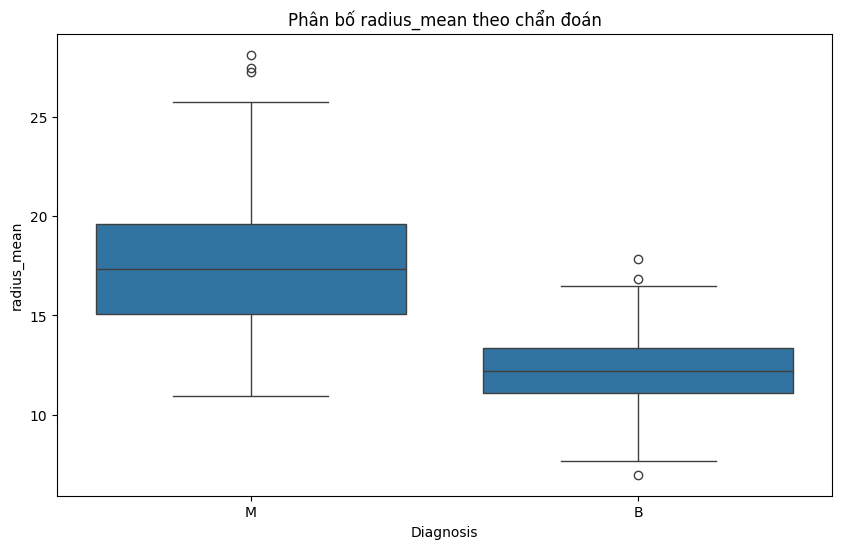

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="diagnosis",
    y="radius_mean"
)

plt.title("Phân bố radius_mean theo chẩn đoán")
plt.xlabel("Diagnosis")
plt.ylabel("radius_mean")

plt.show()

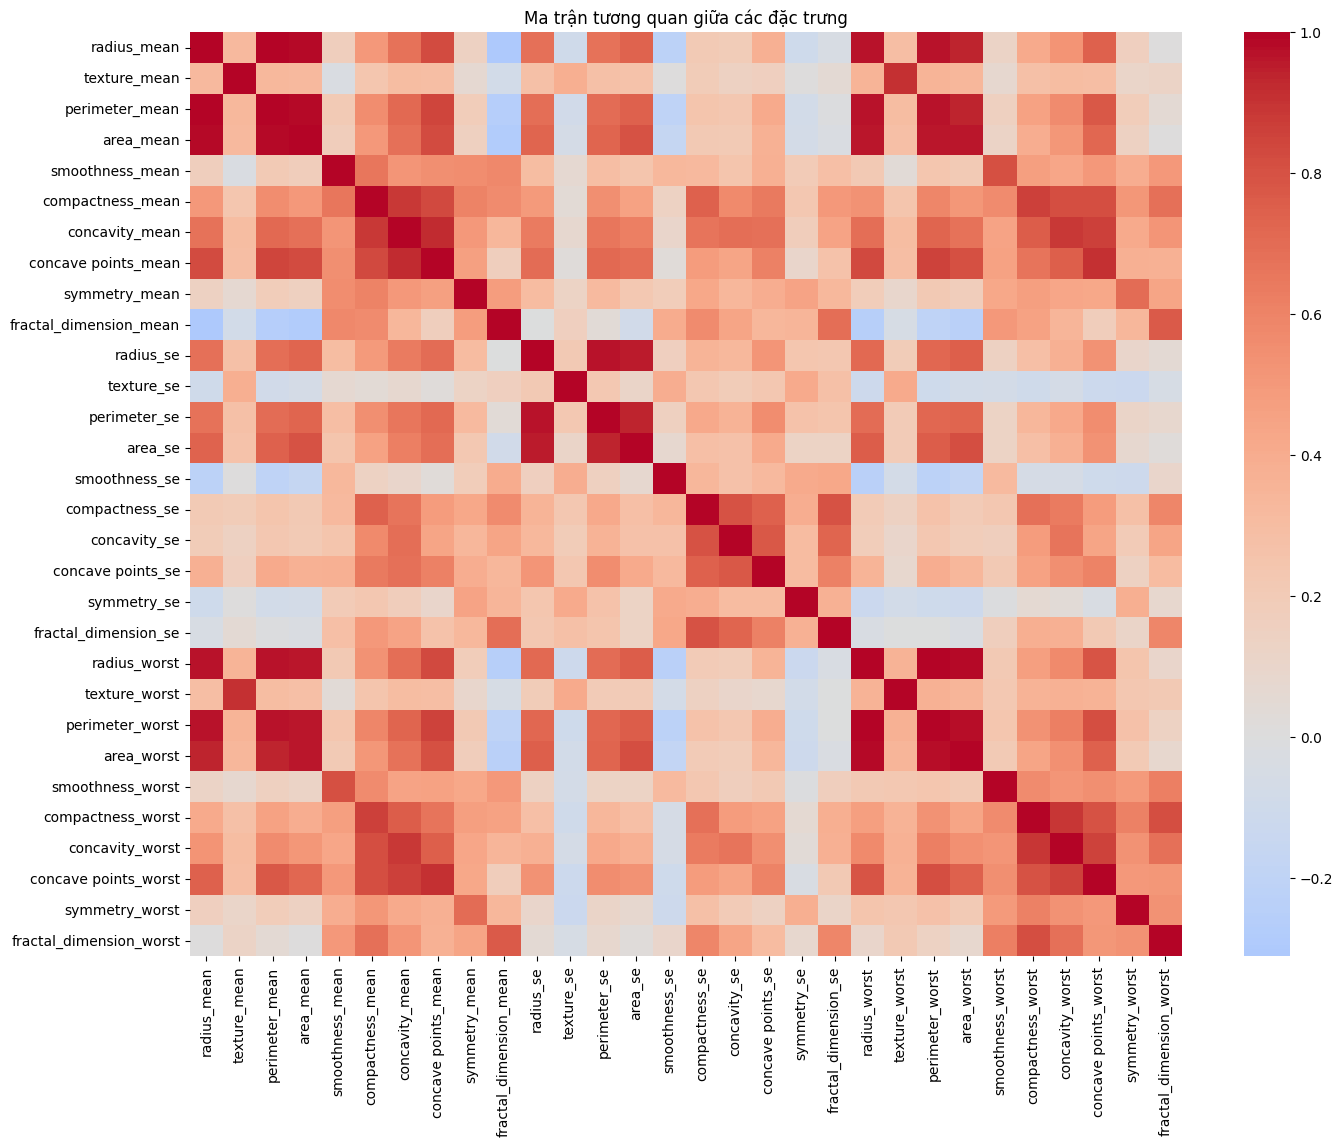

In [ ]:
plt.figure(figsize=(16, 12))

corr = X.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()

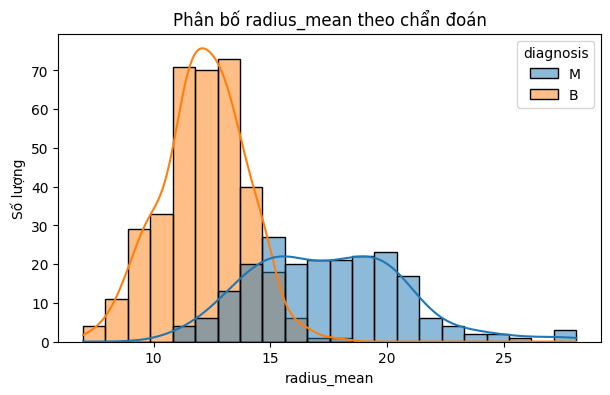

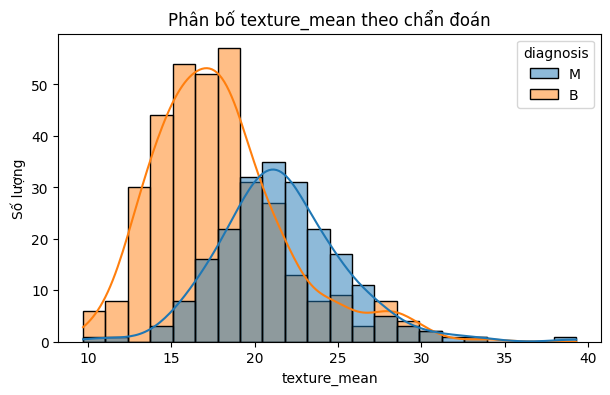

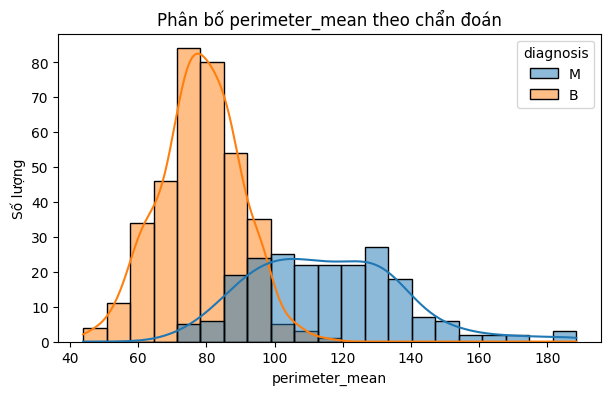

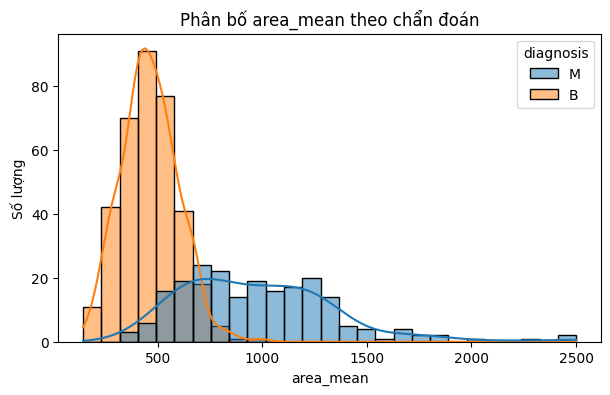

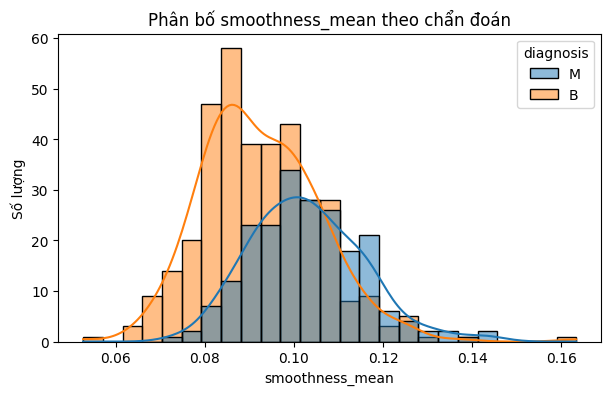

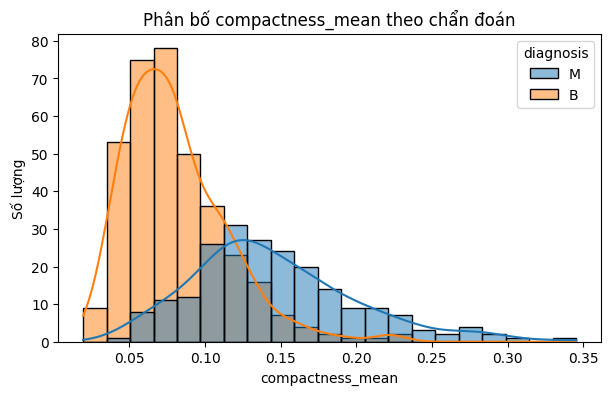

In [ ]:
features_to_plot = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean"
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df_clean,
        x=feature,
        hue="diagnosis",
        kde=True
    )

    plt.title(f"Phân bố {feature} theo chẩn đoán")
    plt.xlabel(feature)
    plt.ylabel("Số lượng")

    plt.show()

In [37]:
# ============================================================
# 4. CHIA DỮ LIỆU TRAIN / TEST
# ============================================================

from sklearn.model_selection import train_test_split

# Chia dữ liệu:
# - 80% dùng để huấn luyện
# - 20% dùng để kiểm tra
# - stratify=y giúp giữ tỷ lệ B/M tương đối giống nhau
# - random_state=42 để kết quả có thể tái lập

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test :", X_test.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước y_test :", y_test.shape)

print("\nPhân bố y_train:")
print(y_train.value_counts())

print("\nPhân bố y_test:")
print(y_test.value_counts())

Kích thước X_train: (455, 30)
Kích thước X_test : (114, 30)
Kích thước y_train: (455,)
Kích thước y_test : (114,)

Phân bố y_train:
diagnosis
B    285
M    170
Name: count, dtype: int64

Phân bố y_test:
diagnosis
B    72
M    42
Name: count, dtype: int64


In [38]:
# ============================================================
# 5. TIỀN XỬ LÝ - STANDARDIZATION
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Chỉ FIT trên tập TRAIN
X_train_scaled = scaler.fit_transform(X_train)

# Tập TEST chỉ được TRANSFORM
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (455, 30)
X_test_scaled : (114, 30)


In [39]:
# Kiểm tra một vài đặc trưng sau khi chuẩn hóa

import pandas as pd

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_train_scaled_df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
radius_mean,455.0,-1.737316e-16,1.001101,-2.009730,-0.686986,-0.231061,0.494783,3.900239
texture_mean,455.0,3.904081e-16,1.001101,-2.265011,-0.719258,-0.120789,0.562843,4.634299
perimeter_mean,455.0,4.704418e-16,1.001101,-1.961360,-0.687765,-0.244467,0.497536,3.899731
area_mean,455.0,-1.171224e-16,1.001101,-1.433461,-0.664343,-0.314364,0.377537,5.114742
smoothness_mean,455.0,7.242070e-16,1.001101,-2.342455,-0.759968,-0.052676,0.623134,4.715773
compactness_mean,455.0,-5.075305e-17,1.001101,-1.568307,-0.744645,-0.214571,0.492380,4.485809
concavity_mean,455.0,-4.489693e-17,1.001101,-1.092835,-0.731107,-0.364967,0.527101,4.137033
concave points_mean,455.0,2.928061e-17,1.001101,-1.236420,-0.739855,-0.395400,0.632163,3.838961
symmetry_mean,455.0,2.342449e-17,1.001101,-2.733834,-0.704202,-0.057834,0.503438,4.435961
fractal_dimension_mean,455.0,3.669836e-16,1.001101,-1.791603,-0.729551,-0.203192,0.524949,4.987148


In [42]:
# ============================================================
# 7. HUẤN LUYỆN 5 MÔ HÌNH
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

# Huấn luyện
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

print("Đã huấn luyện xong tất cả mô hình!")

for name in models:
    print("✓", name)

Đã huấn luyện xong tất cả mô hình!
✓ Logistic Regression
✓ KNN
✓ SVM
✓ Decision Tree
✓ Random Forest


In [43]:
# ============================================================
# 8. DỰ ĐOÁN TRÊN TẬP TEST
# ============================================================

predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_scaled)

print("Đã dự đoán xong!")

for name, pred in predictions.items():
    print(f"{name}: {len(pred)} dự đoán")

Đã dự đoán xong!
Logistic Regression: 114 dự đoán
KNN: 114 dự đoán
SVM: 114 dự đoán
Decision Tree: 114 dự đoán
Random Forest: 114 dự đoán


In [44]:
# ============================================================
# 9. ĐÁNH GIÁ 5 MÔ HÌNH
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in models.items():

    # Nhãn dự đoán
    y_pred = predictions[name]

    # Xác suất dự đoán lớp M (Malignant)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            pos_label="M"
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            pos_label="M"
        ),

        "F1-score": f1_score(
            y_test,
            y_pred,
            pos_label="M"
        ),

        "ROC-AUC": roc_auc_score(
            (y_test == "M").astype(int),
            y_prob
        )
    })

# Chuyển thành DataFrame
results_df = pd.DataFrame(results)

# Hiển thị
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,KNN,0.956140,0.974359,0.904762,0.938272,0.982308
2,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
3,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603
4,Random Forest,0.964912,1.000000,0.904762,0.950000,0.994213


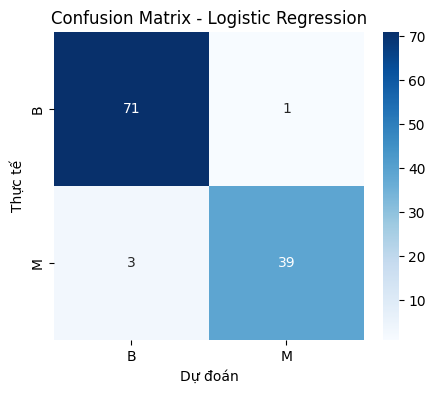

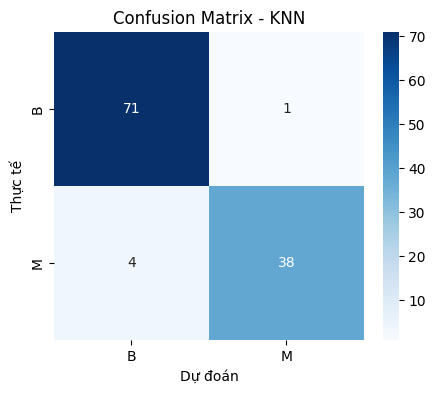

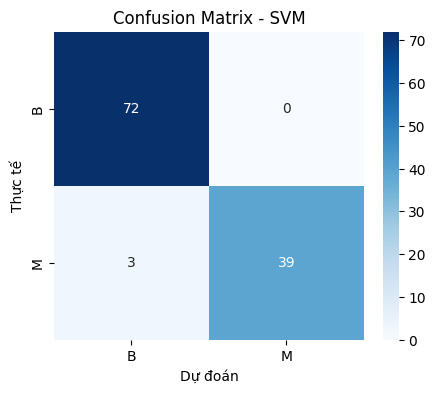

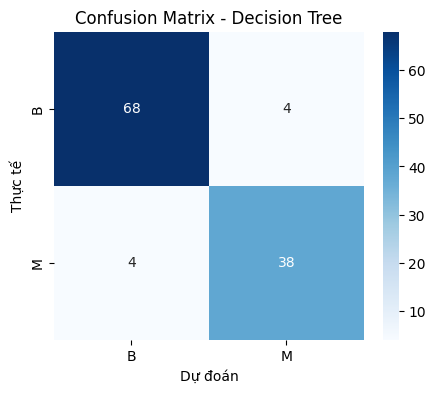

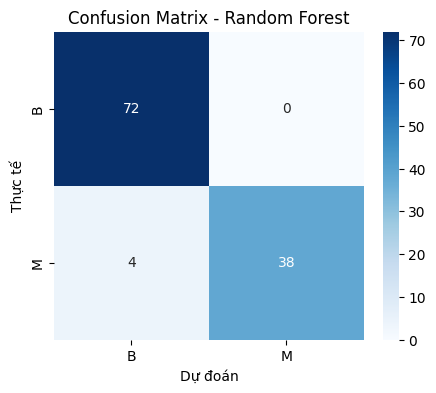

In [45]:
# ============================================================
# 10. CONFUSION MATRIX CHO 5 MÔ HÌNH
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():

    y_pred = predictions[name]

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["B", "M"]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["B", "M"],
        yticklabels=["B", "M"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")

    plt.show()

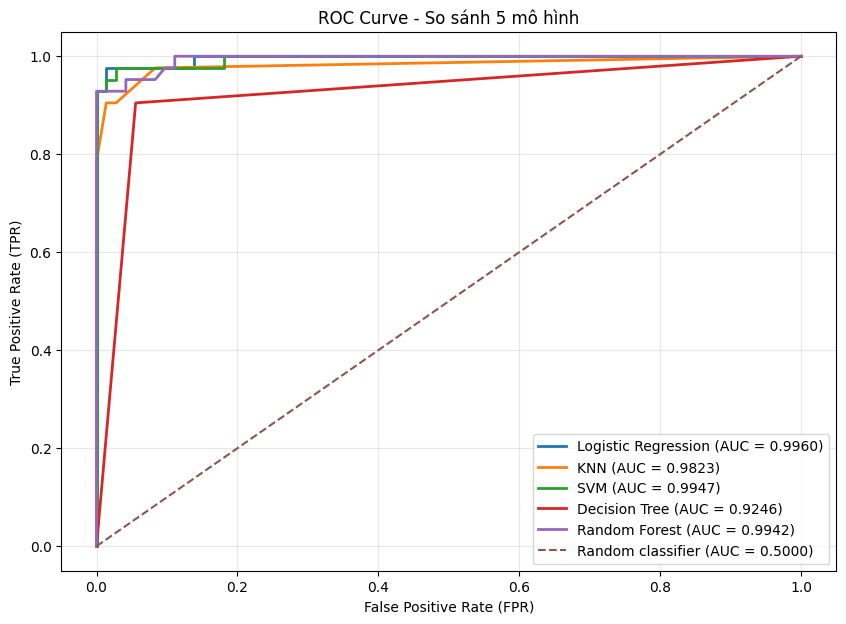

In [46]:
# ============================================================
# 11. ROC CURVE CỦA 5 MÔ HÌNH
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Xác suất thuộc lớp M
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Chuyển y_test: B = 0, M = 1
    y_test_binary = (y_test == "M").astype(int)

    # Tính FPR và TPR
    fpr, tpr, thresholds = roc_curve(
        y_test_binary,
        y_prob
    )

    # Tính AUC
    auc = roc_auc_score(
        y_test_binary,
        y_prob
    )

    # Vẽ ROC
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc:.4f})"
    )

# Đường tham chiếu ngẫu nhiên
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - So sánh 5 mô hình")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

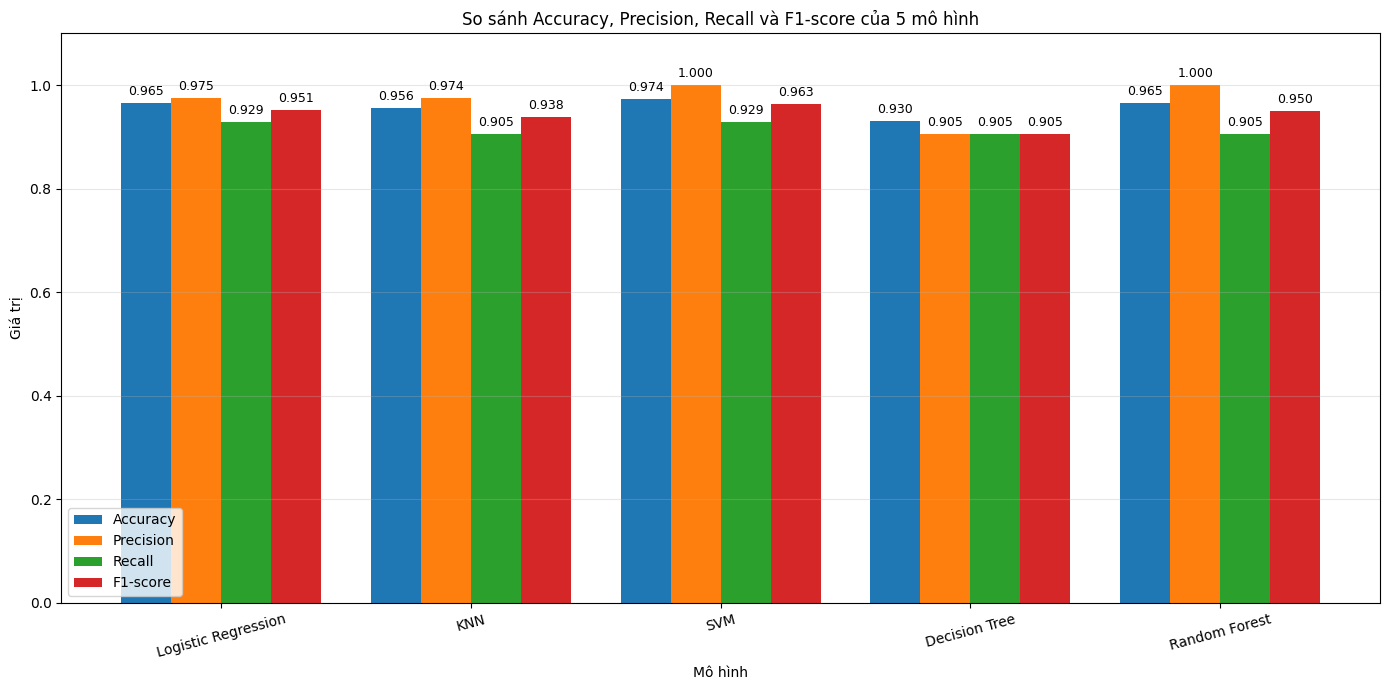

In [47]:
# ============================================================
# 12. SO SÁNH ACCURACY, PRECISION, RECALL VÀ F1-SCORE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Tên các model
models_name = results_df["Model"].values

# Các chỉ số cần vẽ
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

# Vị trí các model trên trục X
x = np.arange(len(models_name))

# Độ rộng mỗi cột
width = 0.2

plt.figure(figsize=(14, 7))

# Vẽ từng nhóm chỉ số
for i, metric in enumerate(metrics):
    values = results_df[metric].values

    bars = plt.bar(
        x + (i - 1.5) * width,
        values,
        width,
        label=metric
    )

    # Hiển thị giá trị trên đầu cột
    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xlabel("Mô hình")
plt.ylabel("Giá trị")
plt.title(
    "So sánh Accuracy, Precision, Recall và F1-score "
    "của 5 mô hình"
)

plt.xticks(
    x,
    models_name,
    rotation=15
)

plt.ylim(0, 1.1)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# B13. LƯU KẾT QUẢ VÀ BIỂU ĐỒ VÀO docs/figures
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Đường dẫn repository
# ------------------------------------------------------------

REPO_PATH = "/content/18_10123154_12523066_CDUTV"

FIGURES_PATH = os.path.join(
    REPO_PATH,
    "docs",
    "figures"
)

os.makedirs(FIGURES_PATH, exist_ok=True)

print("Repository:", REPO_PATH)
print("Figures:", FIGURES_PATH)

Repository: /content/18_10123154_12523066_CDUTV
Figures: /content/18_10123154_12523066_CDUTV/docs/figures


In [49]:
# ============================================================
# LƯU BẢNG KẾT QUẢ
# ============================================================

RESULT_PATH = os.path.join(
    REPO_PATH,
    "docs",
    "model_comparison_my_results.csv"
)

results_df.to_csv(
    RESULT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("✓ Đã lưu:", RESULT_PATH)

✓ Đã lưu: /content/18_10123154_12523066_CDUTV/docs/model_comparison_my_results.csv


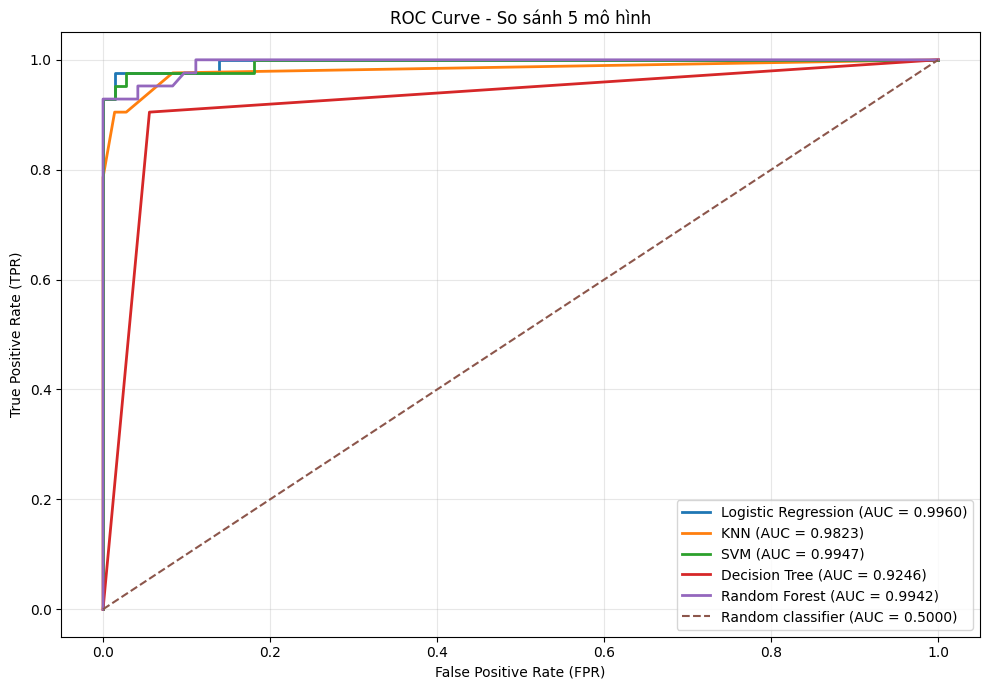

✓ Đã lưu: /content/18_10123154_12523066_CDUTV/docs/figures/roc_curve_5_models.png


In [50]:
# ============================================================
# LƯU ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_test_binary = (y_test == "M").astype(int)

plt.figure(figsize=(10, 7))

for name, model in models.items():

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test_binary,
        y_prob
    )

    auc = roc_auc_score(
        y_test_binary,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc:.4f})"
    )

# Đường tham chiếu
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - So sánh 5 mô hình")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

ROC_PATH = os.path.join(
    FIGURES_PATH,
    "roc_curve_5_models.png"
)

plt.savefig(
    ROC_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✓ Đã lưu:", ROC_PATH)

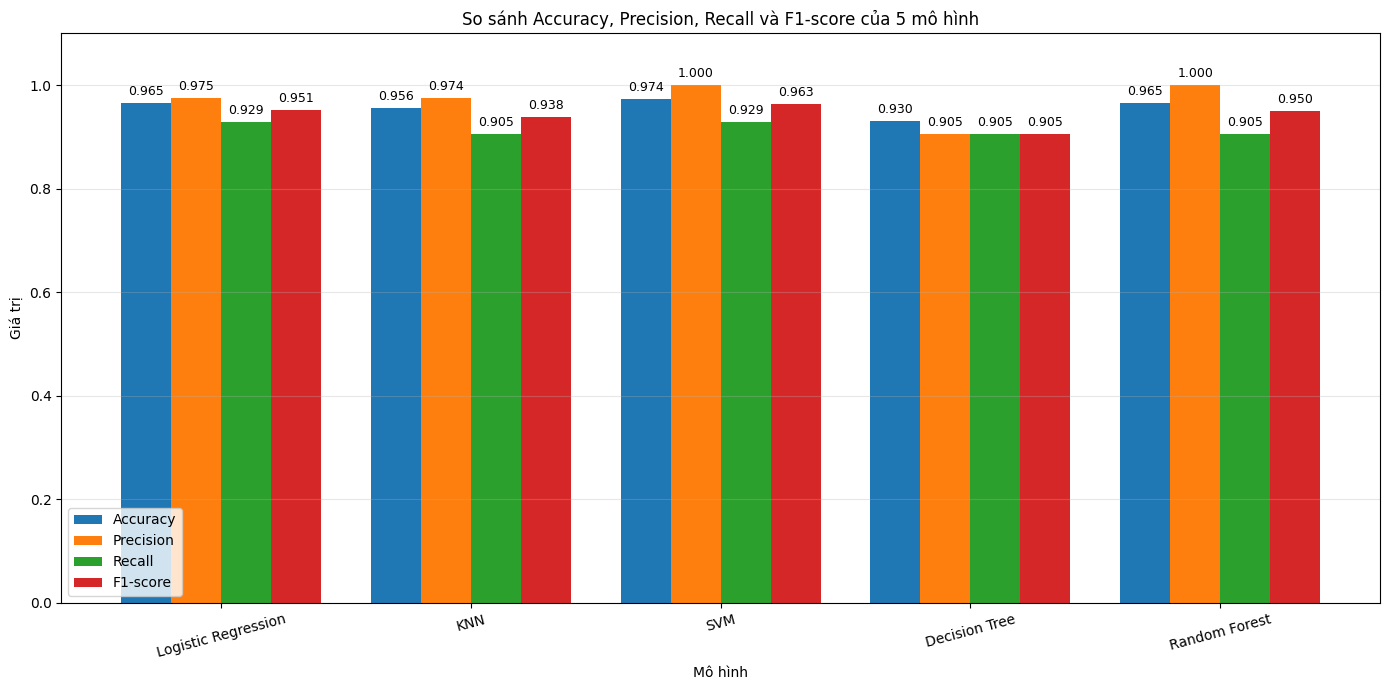

✓ Đã lưu: /content/18_10123154_12523066_CDUTV/docs/figures/model_metrics_comparison.png


In [51]:
# ============================================================
# LƯU BIỂU ĐỒ SO SÁNH 4 METRIC
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

model_names = results_df["Model"].values

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(14, 7))

for i, metric in enumerate(metrics):

    values = results_df[metric].values

    bars = plt.bar(
        x + (i - 1.5) * width,
        values,
        width,
        label=metric
    )

    # Hiển thị số trên đầu cột
    for bar, value in zip(bars, values):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xlabel("Mô hình")
plt.ylabel("Giá trị")

plt.title(
    "So sánh Accuracy, Precision, Recall và F1-score "
    "của 5 mô hình"
)

plt.xticks(
    x,
    model_names,
    rotation=15
)

plt.ylim(0, 1.1)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

METRICS_PATH = os.path.join(
    FIGURES_PATH,
    "model_metrics_comparison.png"
)

plt.savefig(
    METRICS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✓ Đã lưu:", METRICS_PATH)

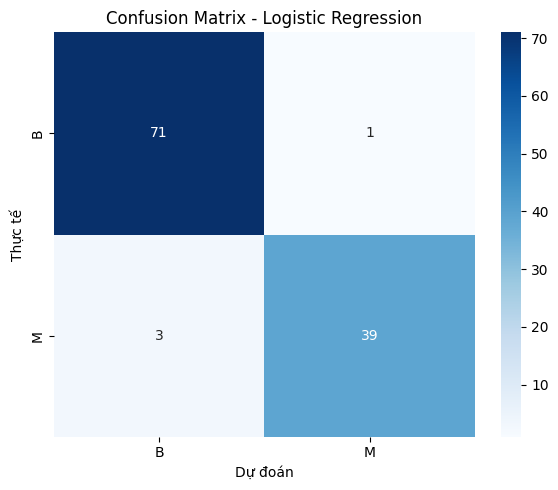

✓ /content/18_10123154_12523066_CDUTV/docs/figures/confusion_matrix_logistic_regression.png


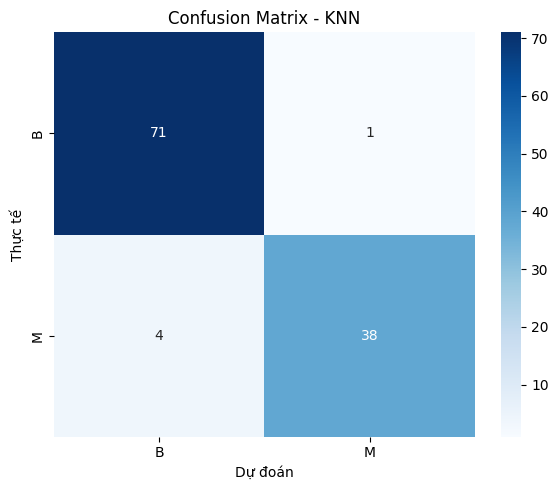

✓ /content/18_10123154_12523066_CDUTV/docs/figures/confusion_matrix_knn.png


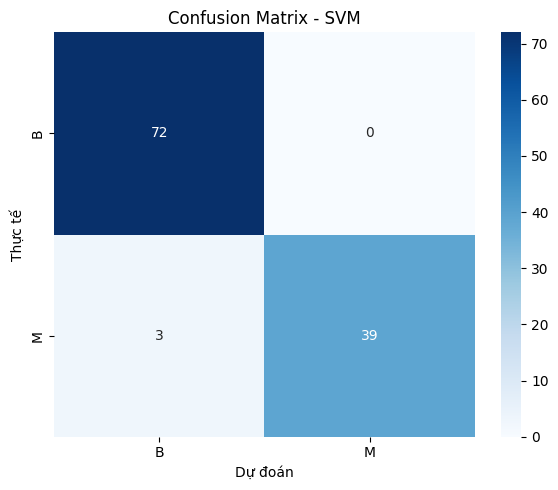

✓ /content/18_10123154_12523066_CDUTV/docs/figures/confusion_matrix_svm.png


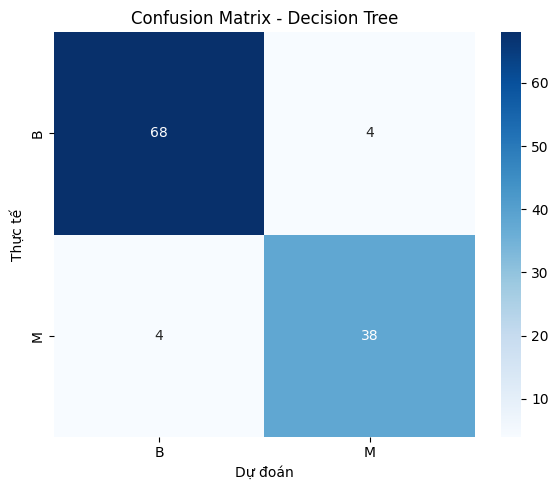

✓ /content/18_10123154_12523066_CDUTV/docs/figures/confusion_matrix_decision_tree.png


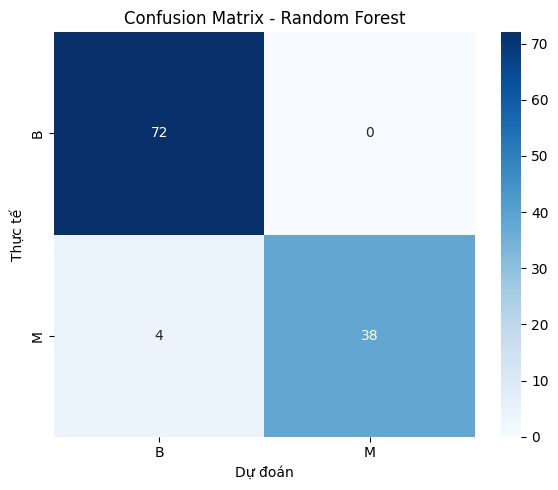

✓ /content/18_10123154_12523066_CDUTV/docs/figures/confusion_matrix_random_forest.png


In [52]:
# ============================================================
# LƯU CONFUSION MATRIX CỦA 5 MODEL
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

for name, model in models.items():

    y_pred = predictions[name]

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["B", "M"]
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["B", "M"],
        yticklabels=["B", "M"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")

    plt.tight_layout()

    # Tạo tên file an toàn
    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    path = os.path.join(
        FIGURES_PATH,
        f"confusion_matrix_{filename}.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("✓", path)

In [53]:
# ============================================================
# KIỂM TRA FILE ĐÃ LƯU
# ============================================================

print("\n===== docs/figures =====")

for filename in sorted(os.listdir(FIGURES_PATH)):
    filepath = os.path.join(FIGURES_PATH, filename)

    size_kb = os.path.getsize(filepath) / 1024

    print(f"✓ {filename:<45} {size_kb:.1f} KB")

print("\n===== docs =====")

docs_path = os.path.join(REPO_PATH, "docs")

for filename in sorted(os.listdir(docs_path)):
    if os.path.isfile(os.path.join(docs_path, filename)):
        print("✓", filename)


===== docs/figures =====
✓ .gitkeep                                      0.0 KB
✓ confusion_matrix_decision_tree.png            58.4 KB
✓ confusion_matrix_knn.png                      54.6 KB
✓ confusion_matrix_logistic_regression.png      61.7 KB
✓ confusion_matrix_random_forest.png            61.6 KB
✓ confusion_matrix_svm.png                      58.6 KB
✓ eda1_target.png                               23.4 KB
✓ eda2_hist.png                                 114.0 KB
✓ eda3_missing.png                              112.4 KB
✓ eda4_corr.png                                 219.2 KB
✓ eda5_box.png                                  117.2 KB
✓ eda6_pair.png                                 579.4 KB
✓ model_metrics_comparison.png                  206.6 KB
✓ roc_curve_5_models.png                        249.6 KB

===== docs =====
✓ baocao.docx
✓ model_comparison .csv
✓ model_comparison_my_results.csv


In [55]:
%cd /content/18_10123154_12523066_CDUTV

!git fetch origin
!git checkout feature/breast-cancer-ml
!git status

/content/18_10123154_12523066_CDUTV
branch 'feature/breast-cancer-ml' set up to track 'origin/feature/breast-cancer-ml'.
Switched to a new branch 'feature/breast-cancer-ml'
On branch feature/breast-cancer-ml
Your branch is up to date with 'origin/feature/breast-cancer-ml'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	docs/figures/confusion_matrix_decision_tree.png
	docs/figures/confusion_matrix_knn.png
	docs/figures/confusion_matrix_logistic_regression.png
	docs/figures/confusion_matrix_random_forest.png
	docs/figures/confusion_matrix_svm.png
	docs/figures/model_metrics_comparison.png
	docs/figures/roc_curve_5_models.png
	docs/model_comparison_my_results.csv

nothing added to commit but untracked files present (use "git add" to track)


In [56]:
!ls -lh ai-models/colab/

total 1012K
-rw-r--r-- 1 root root 938K Sep 24 19:17 01_eda.ipynb
-rw-r--r-- 1 root root 6.3K Sep 24 19:17 02_preprocess.ipynb
-rw-r--r-- 1 root root  61K Sep 24 19:17 03_train.ipynb


In [57]:
!git status --short

?? docs/figures/confusion_matrix_decision_tree.png
?? docs/figures/confusion_matrix_knn.png
?? docs/figures/confusion_matrix_logistic_regression.png
?? docs/figures/confusion_matrix_random_forest.png
?? docs/figures/confusion_matrix_svm.png
?? docs/figures/model_metrics_comparison.png
?? docs/figures/roc_curve_5_models.png
?? docs/model_comparison_my_results.csv


In [54]:
%cd /content/18_10123154_12523066_CDUTV
!git status
!git branch --show-current

/content/18_10123154_12523066_CDUTV
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	docs/figures/confusion_matrix_decision_tree.png
	docs/figures/confusion_matrix_knn.png
	docs/figures/confusion_matrix_logistic_regression.png
	docs/figures/confusion_matrix_random_forest.png
	docs/figures/confusion_matrix_svm.png
	docs/figures/model_metrics_comparison.png
	docs/figures/roc_curve_5_models.png
	docs/model_comparison_my_results.csv

nothing added to commit but untracked files present (use "git add" to track)
main


In [59]:
from google.colab import files

In [61]:
files.download("ai-models/colab/01_eda.ipynb")